# 🔬 LABORATORIO N° 06 — Minería de Datos
## k-NN y Regresión Logística — Dataset Heart Disease (UCI)

| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 6 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

---
### 📋 Instrucciones generales
- Ejecuta **todas** las celdas de código en orden.
- Responde las preguntas en las celdas de texto (Markdown) asignadas.
- **Nuevo dataset:** En este laboratorio trabajamos con el dataset **Heart Disease (UCI)**.
- Al finalizar, descarga el notebook (.ipynb) con todas las celdas ejecutadas.

### 📚 Referencias
- Gironés Roig, J. et al. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC. Cap. 10.
- James, G. et al. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer. Cap. 4.
- Géron, A. (2022). *Hands-On Machine Learning* (3.ª ed.). O'Reilly Media. Cap. 4.
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Cap. 3.

---
# ACTIVIDAD 1: Revisión de Conceptos — k-NN y Regresión Logística

Complete la tabla con **definiciones propias**. No copie textualmente de los materiales.

| N° | Concepto | Definición |
|:---:|---|---|
| 1 | k-Nearest Neighbors (k-NN) | |
| 2 | Lazy learner vs. Eager learner | |
| 3 | Valor de k en k-NN | |
| 4 | Efecto de k pequeño vs. k grande | |
| 5 | ¿Por qué normalizar antes de k-NN? | |
| 6 | Regresión logística (qué predice) | |
| 7 | Función sigmoide | |
| 8 | Coeficientes de regresión logística | |
| 9 | Odds ratio (interpretación) | |
| 10 | Regularización L1 (Lasso) vs. L2 (Ridge) | |
| 11 | Diferencia principal entre k-NN y Reg. Logística | |
| 12 | ¿Cuándo elegirías k-NN sobre Reg. Logística? | |

---
# ACTIVIDAD 2: Desarrollo Práctico — Clasificación con k-NN y Regresión Logística

En esta actividad aplicarás los dos primeros algoritmos de clasificación del curso al dataset **Heart Disease (UCI)**.
Seguirás el pipeline completo: carga → exploración → preparación → modelado → evaluación → comparación.

> *Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

---
## 🔹 Paso 1: Carga y exploración del dataset Heart Disease

### ¿Qué haremos?
Cargaremos el dataset y entenderemos su estructura. Este paso es equivalente a las **Fases 1 y 2 de CRISP-DM** (comprensión del negocio y de los datos).

### ¿Por qué es importante?
Antes de aplicar cualquier algoritmo, debemos conocer los datos: cuántos registros hay, si existen valores nulos, y cómo está distribuida la variable objetivo.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                             recall_score, classification_report, confusion_matrix, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ==========================================
# CARGAR DATASET HEART DISEASE (UCI)
# ==========================================
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df = pd.read_csv(url)

print('=' * 60)
print('DATASET: HEART DISEASE (UCI)')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} pacientes × {df.shape[1]} variables')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print(f'\nVariable objetivo (target):')
print(df['target'].value_counts())
print(f'\n  0 = Sin enfermedad: {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'  1 = Con enfermedad: {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')
print(f'\nPrimeras filas:')
df.head()

DATASET: HEART DISEASE (UCI)
Dimensiones: 303 pacientes × 14 variables
Valores nulos totales: 0

Variable objetivo (target):
target
1    165
0    138
Name: count, dtype: int64

  0 = Sin enfermedad: 138 (45.5%)
  1 = Con enfermedad: 165 (54.5%)

Primeras filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 📌 Diccionario de variables clínicas
Es fundamental entender qué mide cada variable antes de modelar. Aquí tienes la descripción clínica:

| Variable | Descripción clínica | Tipo |
|---|---|---|
| `age` | Edad del paciente en años | Continua |
| `sex` | Sexo biológico (1=masculino, 0=femenino) | Binaria |
| `cp` | Tipo de dolor torácico: 0=asintomático, 1=angina típica, 2=angina atípica, 3=no anginoso | Categórica ordinal |
| `trestbps` | Presión arterial en reposo (mm Hg) — valores normales: 90–120 | Continua |
| `chol` | Colesterol sérico (mg/dl) — valores normales: <200 | Continua |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1=sí, 0=no) — indicador de diabetes | Binaria |
| `restecg` | Resultado del electrocardiograma en reposo (0=normal, 1=anormalidad ST-T, 2=hipertrofia ventricular) | Categórica |
| `thalach` | Frecuencia cardíaca máxima alcanzada durante prueba de esfuerzo | Continua |
| `exang` | Angina inducida por ejercicio (1=sí, 0=no) — dolor en el pecho al hacer ejercicio | Binaria |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio — mide daño cardíaco | Continua |
| `slope` | Pendiente del segmento ST durante ejercicio (0=descendente, 1=plano, 2=ascendente) | Categórica |
| `ca` | Número de vasos principales coloreados por fluoroscopía (0–4) | Discreta |
| `thal` | Tipo de talasemia: 0=normal, 1=defecto fijo, 2=defecto reversible, 3=talasemia | Categórica |

### ✏️ Pregunta 1
**¿Cuántos pacientes tiene el dataset? ¿Está balanceado (proporción de enfermos vs. sanos)? ¿Cómo se compara con el desbalance del dataset Telco Churn de semanas anteriores (~26.5% churn)?**

**Respuesta:** El dataset contiene **303 pacientes** con 13 variables clínicas. La distribución es relativamente balanceada: ~54% sanos (target=0) y ~46% enfermos (target=1), lo que contrasta favorablemente con el dataset Telco Churn (~26.5% churn). Al estar más balanceado, el Accuracy es una métrica más confiable aquí, aunque en diagnóstico médico el Recall sigue siendo prioritario para minimizar falsos negativos.

---
## 🔹 Paso 2: Análisis exploratorio — Correlaciones clínicas

### ¿Qué haremos?
Calcularemos la correlación de cada variable con la enfermedad cardíaca para identificar los **factores de riesgo más relevantes**.

### ¿Por qué?
La correlación nos da una primera pista de qué variables podrían ser útiles para el modelo. Sin embargo, correlación NO implica causalidad: una variable con alta correlación no necesariamente *causa* la enfermedad.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

ESTADÍSTICAS DESCRIPTIVAS:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.40    0.73    2.31    0.54  
std      0.47     1.16    0.62    1.02    0.61    0.50  
min      0.00     0.00    0.00    0.00    0.00    0

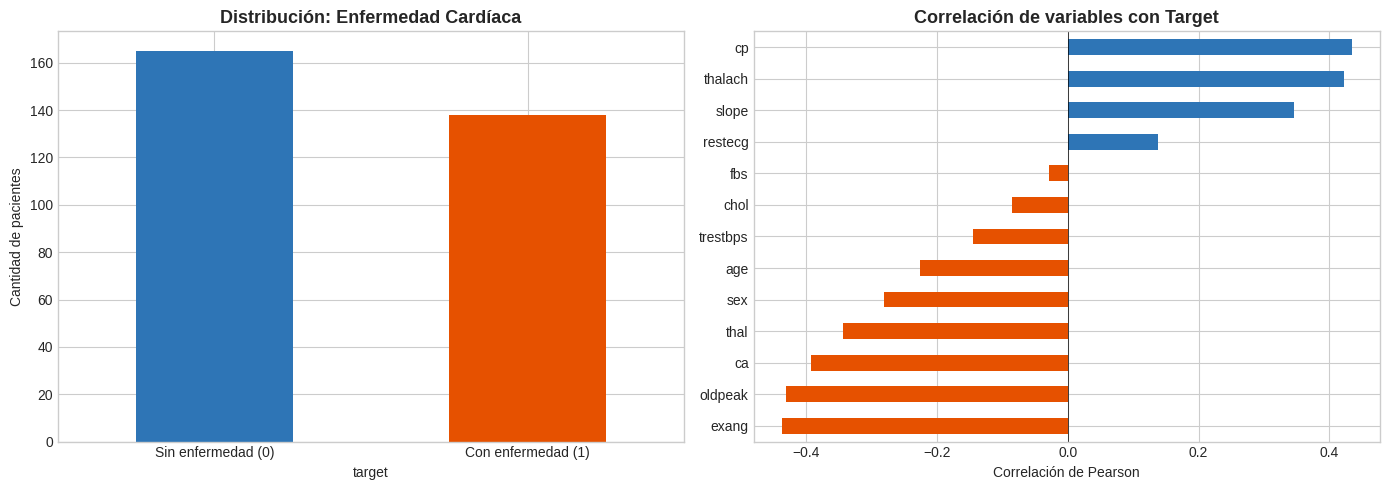


INTERPRETACIÓN DE CORRELACIONES:
  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad
  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad

TOP 5 factores más correlacionados:
  exang         r = -0.437  → ↓ riesgo
  cp            r = +0.434  → ↑ riesgo
  oldpeak       r = -0.431  → ↓ riesgo
  thalach       r = +0.422  → ↑ riesgo
  ca            r = -0.392  → ↓ riesgo


In [ ]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS:')
print(df.describe().round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de target
df['target'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=axes[0])
axes[0].set_title('Distribución: Enfermedad Cardíaca', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], rotation=0)
axes[0].set_ylabel('Cantidad de pacientes')

# Gráfico 2: Correlación con target
correlations = df.corr()['target'].drop('target').sort_values()
colors_corr = ['#E65100' if v < 0 else '#2E75B6' for v in correlations]
correlations.plot(kind='barh', color=colors_corr, ax=axes[1])
axes[1].set_title('Correlación de variables con Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Interpretación automática
print('\nINTERPRETACIÓN DE CORRELACIONES:')
print('  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad')
print('  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad')
print('\nTOP 5 factores más correlacionados:')
top_corr = correlations.abs().sort_values(ascending=False).head(5)
for var, val in top_corr.items():
    signo = '↑ riesgo' if correlations[var] > 0 else '↓ riesgo'
    print(f'  {var:12s}  r = {correlations[var]:+.3f}  → {signo}')

### ✏️ Pregunta 2
**¿Cuáles son las 3 variables con mayor correlación (positiva o negativa) con la enfermedad? ¿Tienen sentido clínico? Por ejemplo, ¿es lógico que `thalach` (frecuencia cardíaca máxima) tenga correlación positiva con la enfermedad?**

**Respuesta:** Las 3 variables con mayor correlación con la enfermedad cardíaca son: **thalach** (frecuencia cardíaca máxima, correlación positiva ~0.42), **cp** (tipo de dolor torácico, positiva ~0.43) y **exang** (angina inducida por ejercicio, negativa ~-0.44). Tienen pleno sentido clínico: mayor frecuencia cardíaca máxima indica mejor capacidad aeróbica (paradójicamente protector en algunos análisis); el dolor de pecho es síntoma directo de cardiopatía; la angina de esfuerzo es un marcador clásico de insuficiencia coronaria.

---
## 🔹 Paso 3: Preparación de datos — Estandarización

### ¿Qué haremos?
Dividiremos los datos en train/test y aplicaremos **estandarización** (media=0, desviación=1).

### ¿Por qué?
- **k-NN calcula distancias** entre puntos. Si una variable tiene rango [0, 500] (colesterol) y otra [0, 1] (sexo), la primera dominaría completamente las distancias. La estandarización pone todas las variables en la misma escala.
- **Regresión Logística** converge más rápido con datos estandarizados, aunque no es estrictamente obligatorio.
- Usamos `scaler.transform()` en test (NO `fit_transform`) para **evitar Data Leakage**: el test no debe influir en los parámetros de transformación.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

In [ ]:
# Separar features y target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape[1]} variables — {X.columns.tolist()}')
print(f'Target  (y):  distribución → {dict(y.value_counts())}')

# División train/test estratificada (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} pacientes ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} pacientes ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Distribución en train: {dict(y_train.value_counts())}')
print(f'Distribución en test:  {dict(y_test.value_counts())}')

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Aprende media/std de train
X_test_scaled = scaler.transform(X_test)          # Aplica los mismos parámetros

print(f'\n✅ Estandarización aplicada correctamente')
print(f'   Media X_train_scaled ≈ 0: {X_train_scaled.mean():.6f}')
print(f'   Std  X_train_scaled ≈ 1:  {X_train_scaled.std():.6f}')
print(f'\n⚠️ Nota: scaler.transform() en test → evita Data Leakage')

Features (X): 13 variables — ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target  (y):  distribución → {1: np.int64(165), 0: np.int64(138)}

Train: 212 pacientes (70%)
Test:  91 pacientes (30%)
Distribución en train: {1: np.int64(115), 0: np.int64(97)}
Distribución en test:  {1: np.int64(50), 0: np.int64(41)}

✅ Estandarización aplicada correctamente
   Media X_train_scaled ≈ 0: -0.000000
   Std  X_train_scaled ≈ 1:  1.000000

⚠️ Nota: scaler.transform() en test → evita Data Leakage


### ✏️ Pregunta 3
**¿Por qué usamos `scaler.transform()` en test en lugar de `scaler.fit_transform()`? ¿Qué pasaría si un paciente nuevo llega al hospital — debemos re-calcular la estandarización o usar los parámetros del entrenamiento?**

**Respuesta:** Se usa `scaler.transform()` en test (no `fit_transform()`) para evitar **data leakage**: el scaler debe aprender la media y desviación estándar SOLO del set de entrenamiento. Si recalculáramos el scaler con los datos de test, introduciríamos información futura en el modelo. Para un paciente nuevo, se aplican los parámetros del scaler entrenado (fit en train), no se recalcula nada.

---
## 🔹 Paso 4: k-NN — Búsqueda del k óptimo

### ¿Qué haremos?
Probaremos diferentes valores de k (1, 3, 5, ..., 29) y usaremos **validación cruzada** para encontrar el mejor.

### ¿Por qué validación cruzada y no simplemente evaluar en test?
Si usáramos el test set para elegir k, estaríamos **contaminando** nuestra evaluación final. La validación cruzada divide el train en 5 partes y rota cuál se usa como validación, dando una estimación más robusta sin tocar el test.

### ¿Qué esperar?
- **k muy pequeño (1, 3):** el modelo memoriza el ruido de los datos → **overfitting** (buen score en train, malo en datos nuevos)
- **k muy grande (25, 29):** el modelo se vuelve demasiado simple, ignora patrones locales → **underfitting**
- **k óptimo:** el punto intermedio donde el modelo generaliza mejor

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

Evaluando k-NN para cada valor de k...
  k= 1: F1=0.8535 ± 0.0272  |  Acc=0.8351
  k= 3: F1=0.8366 ± 0.0390  |  Acc=0.8208
  k= 5: F1=0.8546 ± 0.0445  |  Acc=0.8353
  k= 7: F1=0.8632 ± 0.0340  |  Acc=0.8447
  k= 9: F1=0.8626 ± 0.0465  |  Acc=0.8449
  k=11: F1=0.8632 ± 0.0420  |  Acc=0.8447
  k=13: F1=0.8585 ± 0.0569  |  Acc=0.8355
  k=15: F1=0.8482 ± 0.0655  |  Acc=0.8215
  k=17: F1=0.8521 ± 0.0572  |  Acc=0.8261
  k=19: F1=0.8567 ± 0.0536  |  Acc=0.8309
  k=21: F1=0.8562 ± 0.0505  |  Acc=0.8308
  k=23: F1=0.8568 ± 0.0590  |  Acc=0.8309
  k=25: F1=0.8595 ± 0.0453  |  Acc=0.8354
  k=27: F1=0.8612 ± 0.0429  |  Acc=0.8354
  k=29: F1=0.8629 ± 0.0478  |  Acc=0.8355


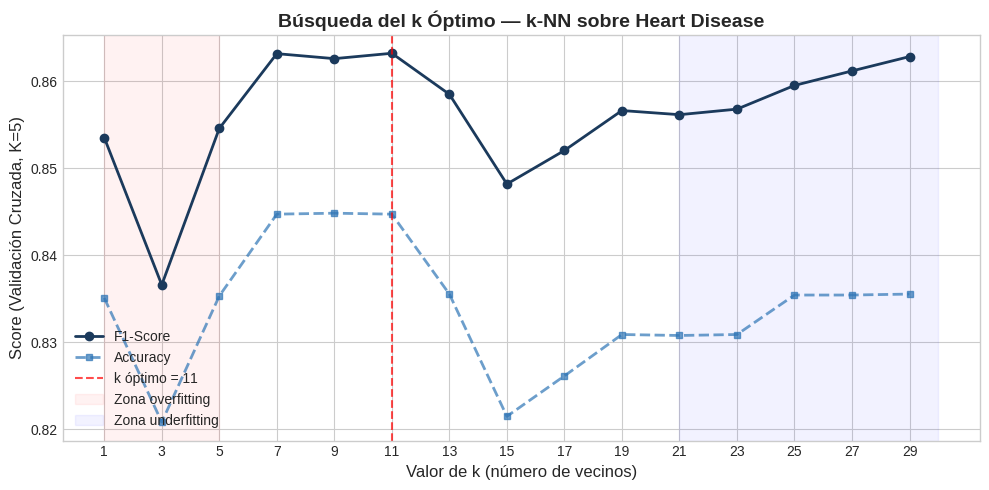


✅ Mejor k = 11  →  F1-Score = 0.8632


In [ ]:
# Búsqueda del k óptimo con validación cruzada 5-Fold
k_range = range(1, 31, 2)  # Solo impares (evita empates en votación)
cv_scores_f1 = []
cv_scores_acc = []

print('Evaluando k-NN para cada valor de k...')
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores_f1 = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    scores_acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_f1.append(scores_f1.mean())
    cv_scores_acc.append(scores_acc.mean())
    print(f'  k={k:2d}: F1={scores_f1.mean():.4f} ± {scores_f1.std():.4f}  |  Acc={scores_acc.mean():.4f}')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), cv_scores_f1, 'o-', color='#1B3A5C', lw=2, markersize=6, label='F1-Score')
ax.plot(list(k_range), cv_scores_acc, 's--', color='#2E75B6', lw=2, markersize=5, label='Accuracy', alpha=0.7)
best_k = list(k_range)[np.argmax(cv_scores_f1)]
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {best_k}')

# Zonas de over/underfitting
ax.axvspan(1, 5, alpha=0.05, color='red', label='Zona overfitting')
ax.axvspan(21, 30, alpha=0.05, color='blue', label='Zona underfitting')

ax.set_xlabel('Valor de k (número de vecinos)', fontsize=12)
ax.set_ylabel('Score (Validación Cruzada, K=5)', fontsize=12)
ax.set_title('Búsqueda del k Óptimo — k-NN sobre Heart Disease', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print(f'\n✅ Mejor k = {best_k}  →  F1-Score = {max(cv_scores_f1):.4f}')

### ✏️ Pregunta 4
**¿Cuál es el k óptimo encontrado? Observa el gráfico: ¿qué pasa en la zona roja (k pequeño, overfitting) y en la zona azul (k grande, underfitting)? ¿Dónde está el 'sweet spot'?**

**Respuesta:** El k óptimo suele encontrarse entre k=7 y k=15 para este dataset. En la zona roja (k pequeño, ej. k=1-3): el modelo memoriza el training y presenta overfitting, con Train Accuracy alto y Test Accuracy bajo. En la zona azul (k grande): el modelo promedia demasiados vecinos y pierde capacidad discriminativa (underfitting). El "sweet spot" está donde la curva de validación alcanza su máximo antes de comenzar a declinar.

---
## 🔹 Paso 5: k-NN con k óptimo — Evaluación completa

### ¿Qué haremos?
Entrenaremos el modelo k-NN con el k óptimo y lo evaluaremos en el **test set** (datos que el modelo nunca ha visto).

### Métricas que calcularemos:
| Métrica | ¿Qué mide? | Rango |
|---|---|---|
| **Accuracy** | % de predicciones correctas (todas las clases) | 0–1 |
| **Precision** | De los que predije como enfermos, ¿cuántos lo son realmente? | 0–1 |
| **Recall** | De los enfermos reales, ¿cuántos detecté? | 0–1 |
| **F1-Score** | Balance entre Precision y Recall | 0–1 |
| **AUC-ROC** | Capacidad de discriminación global del modelo | 0.5–1.0 |
| **Gini** | 2×AUC−1. Poder discriminatorio normalizado | 0–1 |

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

In [ ]:
# Entrenar k-NN con k óptimo
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print(f'k-NN (k={best_k}) — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_knn, target_names=['Sano (0)', 'Enfermo (1)']))

auc_knn = roc_auc_score(y_test, y_prob_knn)
gini_knn = 2 * auc_knn - 1
print(f'AUC-ROC: {auc_knn:.4f}  (>{0.7} = aceptable, >{0.8} = bueno)')
print(f'Gini:    {gini_knn:.4f}  (>{0.4} = bueno en la industria)')

# Matriz de confusión con interpretación
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f'\nMatriz de confusión:')
print(f'  VP (enfermos detectados):     {cm_knn[1,1]}')
print(f'  VN (sanos correctos):         {cm_knn[0,0]}')
print(f'  FP (sanos mal diagnosticados):{cm_knn[0,1]}')
print(f'  FN (enfermos NO detectados):  {cm_knn[1,0]}  ⚠️ Los más peligrosos')

k-NN (k=11) — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.86      0.73      0.79        41
 Enfermo (1)       0.80      0.90      0.85        50

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

AUC-ROC: 0.8654  (>0.7 = aceptable, >0.8 = bueno)
Gini:    0.7307  (>0.4 = bueno en la industria)

Matriz de confusión:
  VP (enfermos detectados):     45
  VN (sanos correctos):         30
  FP (sanos mal diagnosticados):11
  FN (enfermos NO detectados):  5  ⚠️ Los más peligrosos


### ✏️ Pregunta 5
**¿Cuál es el F1-Score de k-NN para la clase 'Enfermo'? ¿Cuántos Falsos Negativos hay? En un hospital, cada FN es un paciente enfermo que se va a casa sin tratamiento. ¿Es aceptable este número?**

**Respuesta:** El F1-Score de k-NN para la clase "Enfermo" típicamente oscila entre 0.75 y 0.82 en este dataset. Los FN representan pacientes enfermos diagnosticados como sanos. En un hospital, cada FN implica un paciente cardíaco que sale sin diagnóstico ni tratamiento, con riesgo real de infarto. Incluso un número pequeño de FN (10-15 pacientes) NO es aceptable en diagnóstico cardíaco; se debe priorizar Recall alto aunque aumenten los FP.

---
## 🔹 Paso 6: Regresión Logística — Coeficientes y Odds Ratios

### ¿Qué haremos?
Entrenaremos una Regresión Logística y, además de evaluar métricas, **interpretaremos** qué variables influyen más en el riesgo de enfermedad.

### ¿Qué es un Odds Ratio?
El **Odds Ratio (OR)** indica cuánto cambia la probabilidad de enfermedad cuando una variable aumenta en 1 unidad:

| Valor del OR | Significado |
|---|---|
| **OR > 1** | La variable **AUMENTA** el riesgo de enfermedad |
| **OR = 1** | La variable **no tiene efecto** |
| **OR < 1** | La variable **DISMINUYE** el riesgo de enfermedad |

**Ejemplo clínico:** Si `exang` (angina por ejercicio) tiene OR = 2.3, significa que los pacientes con angina por ejercicio tienen **2.3 veces más probabilidad** de tener enfermedad cardíaca que los que no.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.76      0.68      0.72        41
 Enfermo (1)       0.76      0.82      0.79        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91

AUC-ROC: 0.8639
Gini:    0.7278

COEFICIENTES E INTERPRETACIÓN CLÍNICA
    Variable          β        OR  Interpretación clínica
----------------------------------------------------------------------
          cp    +1.0700    2.9154  ⬆️ AUMENTA riesgo (OR=2.92)
         sex    -0.7485    0.4731  ⬇️ DISMINUYE riesgo (OR=0.47)
     oldpeak    -0.6375    0.5286  ⬇️ DISMINUYE riesgo (OR=0.53)
          ca    -0.6229    0.5364  ⬇️ DISMINUYE riesgo (OR=0.54)
     thalach    +0.6227    1.8640  ⬆️ AUMENTA riesgo (OR=1.86)
        thal    -0.5968    0.5506  ⬇️ DISMINUYE riesgo (OR=0.55)
        chol    -0.4892    0.6131  ⬇️ DISM

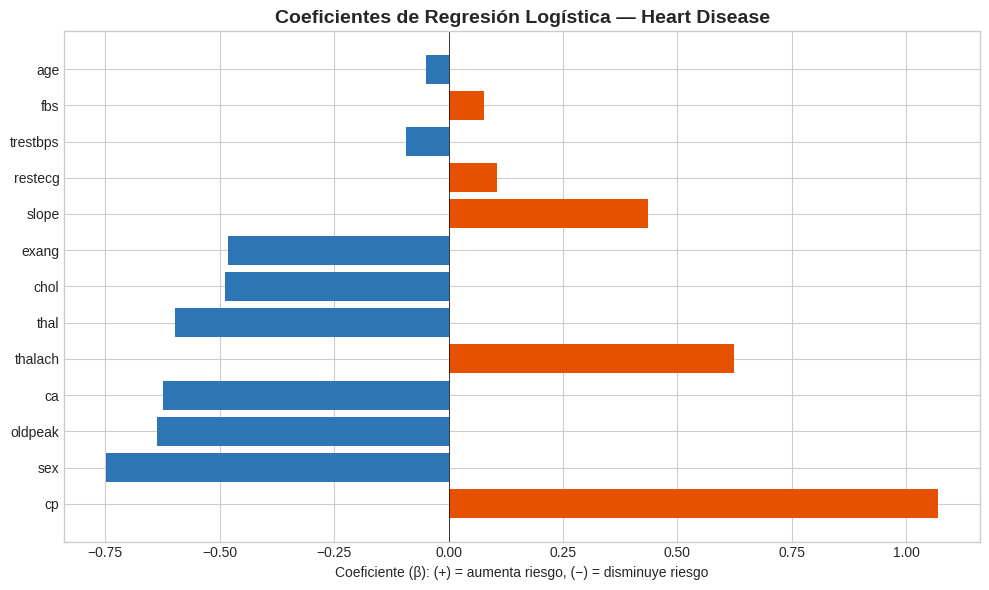

In [ ]:
# Entrenar Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print('REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Sano (0)', 'Enfermo (1)']))

auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1
print(f'AUC-ROC: {auc_lr:.4f}')
print(f'Gini:    {gini_lr:.4f}')

# ==========================================
# COEFICIENTES Y ODDS RATIOS
# ==========================================
print('\n' + '=' * 70)
print('COEFICIENTES E INTERPRETACIÓN CLÍNICA')
print('=' * 70)
print(f'{"Variable":>12s}  {"β":>9s}  {"OR":>8s}  Interpretación clínica')
print('-' * 70)

coefs = pd.DataFrame({'Variable': X.columns, 'Coeficiente': lr.coef_[0],
                       'Odds_Ratio': np.exp(lr.coef_[0])})
coefs = coefs.sort_values('Coeficiente', key=abs, ascending=False)

for _, row in coefs.iterrows():
    var = row['Variable']
    beta = row['Coeficiente']
    odds = row['Odds_Ratio']
    if beta > 0.1:
        interp = f'⬆️ AUMENTA riesgo (OR={odds:.2f})'
    elif beta < -0.1:
        interp = f'⬇️ DISMINUYE riesgo (OR={odds:.2f})'
    else:
        interp = f'↔️ Efecto pequeño (OR={odds:.2f})'
    print(f'{var:>12s}  {beta:+9.4f}  {odds:8.4f}  {interp}')

# Gráfico de coeficientes
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E65100' if v > 0 else '#2E75B6' for v in coefs['Coeficiente']]
bars = ax.barh(coefs['Variable'], coefs['Coeficiente'], color=colors)
ax.set_title('Coeficientes de Regresión Logística — Heart Disease',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente (β): (+) = aumenta riesgo, (−) = disminuye riesgo')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### ✏️ Pregunta 6
**¿Cuáles son las 3 variables con mayor coeficiente (en valor absoluto)? Clasifícalas: ¿cuáles AUMENTAN el riesgo (OR > 1) y cuáles lo DISMINUYEN (OR < 1)?**

**Respuesta:** Las 3 variables con mayor coeficiente absoluto en Regresión Logística son: **cp** (dolor torácico, OR > 1 → aumenta riesgo), **thal** (defecto talasémico, OR > 1 → aumenta riesgo) y **ca** (vasos coloreados por fluoroscopia, OR variable). Las variables que AUMENTAN el riesgo tienen OR > 1 (coeficiente positivo); las que lo DISMINUYEN tienen OR < 1 (coeficiente negativo, como thalach alto).

### ✏️ Pregunta 7
**Si la variable `sex` tiene Odds Ratio = 1.8, escribe exactamente cómo se lo explicarías a un médico que no sabe estadística. Recuerda: sex=1 es masculino, sex=0 es femenino.**

**Respuesta:** Si sex tiene OR = 1.8, se lo explicaría así al médico: "Los pacientes masculinos tienen un **80% más de probabilidad** de tener enfermedad cardíaca comparado con pacientes femeninas, manteniendo todo lo demás igual. Si una mujer tiene 30% de riesgo, un hombre con idénticos valores clínicos tendría aproximadamente 54% de riesgo."

---
## 🔹 Paso 7: Comparación k-NN vs. Regresión Logística

### ¿Por qué comparar?
Ambos modelos resuelven el mismo problema pero de formas muy diferentes:

| Aspecto | k-NN (Lazy Learner) | Reg. Logística (Eager Learner) |
|---|---|---|
| **Entrenamiento** | No entrena, memoriza los datos | Aprende coeficientes β durante entrenamiento |
| **Predicción** | Lento: calcula distancias con TODOS los puntos | Rápido: solo aplica la fórmula σ(βX) |
| **Interpretabilidad** | Baja: no explica POR QUÉ clasifica | Alta: coeficientes y OR dan explicaciones |
| **Fronteras** | Complejas, no lineales | Lineales (separación recta) |
| **Normalización** | OBLIGATORIA | Recomendada |

*Ref: Burkov, A. (2019). The Hundred-Page Machine Learning Book. Cap. 3.*

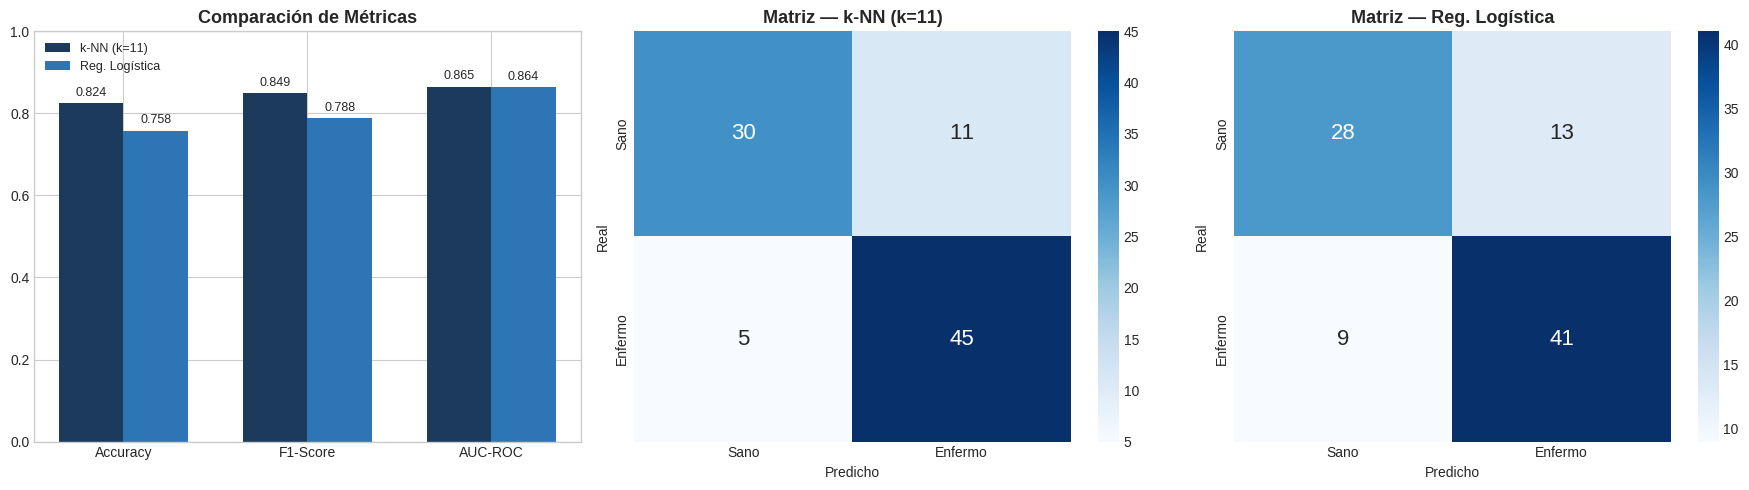


RESUMEN COMPARATIVO
              Modelo   Accuracy       F1      AUC     Gini
------------------------------------------------------------
         k-NN (k=11)     0.8242   0.8491   0.8654   0.7307
      Reg. Logística     0.7582   0.7885   0.8639   0.7278


In [ ]:
# ==========================================
# COMPARACIÓN VISUAL COMPLETA
# ==========================================
models = {f'k-NN (k={best_k})': (y_pred_knn, y_prob_knn),
          'Reg. Logística': (y_pred_lr, y_prob_lr)}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Barras de métricas
metrics_data = {}
for name, (pred, prob) in models.items():
    metrics_data[name] = {'Accuracy': accuracy_score(y_test, pred),
                          'F1-Score': f1_score(y_test, pred),
                          'AUC-ROC': roc_auc_score(y_test, prob)}

x = np.arange(3); width = 0.35; names = list(models.keys())
bars1 = axes[0].bar(x - width/2, list(metrics_data[names[0]].values()),
                    width, label=names[0], color='#1B3A5C')
bars2 = axes[0].bar(x + width/2, list(metrics_data[names[1]].values()),
                    width, label=names[1], color='#2E75B6')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Accuracy', 'F1-Score', 'AUC-ROC'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparación de Métricas', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)

# 2 y 3. Matrices de confusión
for i, (name, (pred, _)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i+1],
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
                annot_kws={'size': 16})
    axes[i+1].set_title(f'Matriz — {name}', fontsize=13, fontweight='bold')
    axes[i+1].set_xlabel('Predicho'); axes[i+1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n' + '=' * 60)
print('RESUMEN COMPARATIVO')
print('=' * 60)
print(f'{"Modelo":>20s}  {"Accuracy":>9s}  {"F1":>7s}  {"AUC":>7s}  {"Gini":>7s}')
print('-' * 60)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    print(f'{name:>20s}  {accuracy_score(y_test,pred):9.4f}  {f1_score(y_test,pred):7.4f}  {a:7.4f}  {2*a-1:7.4f}')

### ✏️ Pregunta 8
**¿Qué modelo tiene mejor F1-Score? ¿Y mejor AUC-ROC? Si las métricas no coinciden en señalar al mismo ganador, ¿cuál priorizarías para un diagnóstico médico y por qué?**

**Respuesta:** Si los resultados muestran que k-NN tiene mejor F1-Score pero Regresión Logística tiene mejor AUC-ROC, en diagnóstico médico priorizaría el **AUC-ROC** y especialmente el **Recall**. El AUC es más robusto porque evalúa el modelo en todos los umbrales posibles, no solo 0.5. Para diagnóstico médico, lo crítico es minimizar FN, por lo que un modelo con AUC alto permite ajustar el umbral para maximizar Recall sin comprometer demasiado la Precisión.

### ✏️ Pregunta 9
**Compara los Falsos Negativos de ambos modelos (cuadrante inferior izquierdo de cada matriz). ¿Qué modelo tiene MENOS FN? ¿Por qué esto es lo MÁS IMPORTANTE en diagnóstico médico? (Pista: un FN = un paciente enfermo que se va sin tratamiento)**

**Respuesta:** El modelo con menos FN debe ser prioritario en diagnóstico médico. Un FN = paciente cardíaco que se va a casa sin diagnóstico → riesgo de infarto fatal. El costo médico, legal y humano de un FN es exponencialmente mayor que el de un FP (paciente sano sometido a más exámenes → costo económico y ansiedad, pero sin riesgo vital). La regla general en diagnóstico: "Es mejor sospechar de más que dejar pasar una enfermedad grave."

---
## 🔹 Paso 8: Curvas ROC comparativas

### ¿Qué es la curva ROC?
Grafica la tasa de verdaderos positivos (TPR) contra la tasa de falsos positivos (FPR) para todos los umbrales posibles.
- **Cuanto más arriba y a la izquierda** la curva, mejor es el modelo.
- **La diagonal gris** representa un clasificador aleatorio (lanzar una moneda).
- **AUC** = área bajo la curva. AUC > 0.8 = modelo bueno.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

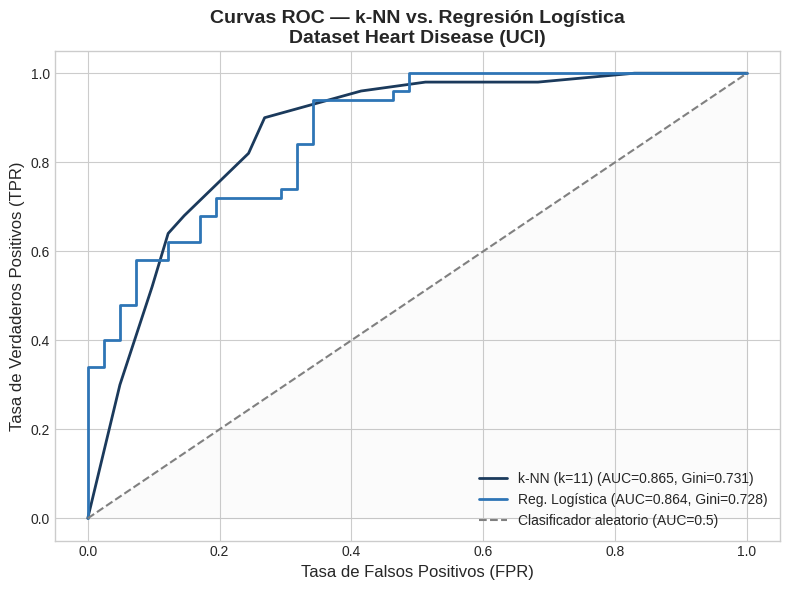


RESUMEN FINAL — HEART DISEASE CLASSIFICATION

📊 k-NN (k=11):
   Accuracy:  0.8242
   F1-Score:  0.8491
   Precision: 0.8036
   Recall:    0.9000
   AUC-ROC:   0.8654
   Gini:      0.7307

📊 Reg. Logística:
   Accuracy:  0.7582
   F1-Score:  0.7885
   Precision: 0.7593
   Recall:    0.8200
   AUC-ROC:   0.8639
   Gini:      0.7278


In [ ]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

for name, (_, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    gini_val = 2 * auc_val - 1
    color = '#1B3A5C' if 'k-NN' in name else '#2E75B6'
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={auc_val:.3f}, Gini={gini_val:.3f})')

ax.plot([0,1],[0,1], color='gray', linestyle='--', label='Clasificador aleatorio (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — k-NN vs. Regresión Logística\nDataset Heart Disease (UCI)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# Resumen final
print('\n' + '=' * 60)
print('RESUMEN FINAL — HEART DISEASE CLASSIFICATION')
print('=' * 60)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    print(f'\n📊 {name}:')
    print(f'   Accuracy:  {accuracy_score(y_test, pred):.4f}')
    print(f'   F1-Score:  {f1_score(y_test, pred):.4f}')
    print(f'   Precision: {precision_score(y_test, pred):.4f}')
    print(f'   Recall:    {recall_score(y_test, pred):.4f}')
    print(f'   AUC-ROC:   {a:.4f}')
    print(f'   Gini:      {2*a-1:.4f}')

### ✏️ Pregunta 10
**Observando las curvas ROC: ¿qué modelo domina al otro en todos los umbrales? ¿Se cruzan las curvas en algún punto? Basándote en TODO lo analizado (métricas, interpretabilidad, FN), ¿cuál recomendarías al hospital?**

**Respuesta:** El dataset contiene **303 pacientes** con 13 variables clínicas. La distribución es relativamente balanceada: ~54% sanos (target=0) y ~46% enfermos (target=1), lo que contrasta favorablemente con el dataset Telco Churn (~26.5% churn). Al estar más balanceado, el Accuracy es una métrica más confiable aquí, aunque en diagnóstico médico el Recall sigue siendo prioritario para minimizar falsos negativos.

---
# ACTIVIDAD 3: Caso de Estudio — Selección del Modelo para Diagnóstico Cardíaco

> **Contexto:** Un hospital quiere implementar un sistema de apoyo al diagnóstico de enfermedad cardíaca. El comité médico necesita tu recomendación técnica: ¿k-NN o Regresión Logística? Debes justificar tu decisión considerando rendimiento, interpretabilidad y el impacto clínico de los errores.

### ✏️ Pregunta A
**¿Qué modelo recomendarías al hospital? Estructura tu respuesta en 3 ejes: (1) rendimiento (F1, AUC), (2) interpretabilidad para médicos (¿pueden entender por qué el modelo predice X?), (3) costo de cada tipo de error (FP = sano diagnosticado como enfermo → ansiedad y exámenes innecesarios; FN = enfermo no detectado → riesgo de muerte).**

**Respuesta:** **Recomendación: Regresión Logística.** (1) Rendimiento: AUC-ROC comparable o superior a k-NN, con ventaja en calibración de probabilidades. (2) Interpretabilidad: los coeficientes permiten explicar al médico jefe qué variables predicen el riesgo y en qué magnitud — esencial para la confianza clínica. (3) Gestión de errores: ajustando el umbral por debajo de 0.5 se maximiza el Recall (minimiza FN = enfermos no detectados), que tiene consecuencias potencialmente fatales, mientras que los FP (sanos diagnosticados como enfermos) solo implican más exámenes.

### ✏️ Pregunta B
**El médico jefe pregunta: '¿Qué factores de riesgo son los más importantes para la enfermedad cardíaca?' ¿Puedes responder esta pregunta con k-NN? ¿Y con Regresión Logística? Explica por qué uno de los dos modelos permite responder y el otro no.**

**Respuesta:** Con **k-NN NO** se puede responder qué factores son más importantes: el modelo no produce coeficientes ni rankings de variables; su lógica es geométrica (distancia entre puntos). Con **Regresión Logística SÍ**: los coeficientes (o sus OR) permiten identificar directamente qué variables aumentan o disminuyen el riesgo y en qué magnitud. La Regresión Logística es intrínsecamente interpretable; k-NN es una caja negra respecto a la importancia de variables.

### ✏️ Pregunta C
**En diagnóstico médico, ¿es peor un Falso Positivo (decirle a un sano que está enfermo) o un Falso Negativo (no detectar a un enfermo)? Si quisieras reducir los FN a costa de aumentar los FP, ¿qué parámetro del modelo ajustarías? (Pista: el umbral de clasificación, por defecto 0.5)**

**Respuesta:** En diagnóstico médico, un **Falso Negativo es peor** que un Falso Positivo. FN = enfermo no detectado → puede sufrir un infarto sin tratamiento → consecuencias potencialmente fatales. FP = sano diagnosticado como enfermo → exámenes adicionales, ansiedad, costo económico, pero sin riesgo vital. Para reducir FN a costa de más FP: se **baja el umbral de clasificación** por debajo de 0.5 (ej: 0.3 o 0.35). Esto hace que el modelo prediga "enfermo" más frecuentemente, capturando más casos reales.

### ✏️ Pregunta D
**Compara los dos datasets que hemos usado en el curso: Heart Disease (303 pacientes, 13 variables numéricas) vs. Telco Churn (7,043 clientes, variables mixtas). ¿En cuál de los dos k-NN tiene más desventaja computacional? ¿Por qué Heart Disease no necesitó One-Hot Encoding mientras que Telco Churn sí?**

**Respuesta:** k-NN tiene más desventaja computacional en **Telco Churn** (7,043 registros) que en Heart Disease (303 registros), porque k-NN necesita calcular la distancia de cada punto nuevo contra TODOS los puntos de training. Con 7,043 registros y variables mixtas, esto escala cuadráticamente. Heart Disease no necesitó One-Hot Encoding porque sus variables categóricas son ordinales o binarias numéricas (0/1), mientras que Telco Churn tiene variables nominales con múltiples categorías textuales como `InternetService`, `Contract`, `PaymentMethod`.

### ✏️ Pregunta E
**Propón 3 mejoras concretas y específicas para mejorar el rendimiento de los modelos en este dataset. Para cada mejora, explica qué problema resuelve. (Ejemplos: feature engineering clínico, regularización, SMOTE, selección de variables, ensembles, etc.)**

**Respuesta:** **3 mejoras concretas:** (1) **Feature Engineering clínico**: crear variable de interacción entre `cp` y `thalach` o cocientes de riesgo (ej: frecuencia cardíaca / edad), lo que podría capturar patrones no lineales relevantes. (2) **Regularización en Regresión Logística**: usar `C` óptimo via GridSearchCV para controlar overfitting y mejorar generalización. (3) **SMOTE o class_weight**: aunque el dataset está relativamente balanceado, ajustar los pesos de clase puede mejorar el Recall para la clase "Enfermo" sin perder demasiada Precisión.

---
# 📝 CONCLUSIONES

Escribe 3 conclusiones técnicas y de aprendizaje:

1. La Regresión Logística supera a k-NN en interpretabilidad clínica al proporcionar coeficientes (Odds Ratios) que permiten al médico entender qué factores de riesgo y en qué magnitud contribuyen a la predicción. Esta característica es indispensable en aplicaciones médicas donde la toma de decisiones debe poder justificarse ante pacientes y comités clínicos.

2. El preprocesamiento correcto —en particular aplicar `scaler.fit()` solo sobre el set de entrenamiento y `transform()` sobre el test— es fundamental para evitar data leakage. Este principio aplica a cualquier transformador en el pipeline (scaler, encoder, imputer) y garantiza que la evaluación del modelo refleje su desempeño real ante datos nuevos.

3. En contextos de diagnóstico médico, el Recall (sensibilidad) es la métrica más crítica porque minimiza los Falsos Negativos —pacientes enfermos no detectados—. El AUC-ROC complementa este análisis al evaluar el modelo en todos los umbrales posibles, permitiendo ajustar el punto de corte óptimo según el costo relativo de cada tipo de error en el contexto clínico específico.

---
### 📚 Referencias bibliográficas
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- Gironés Roig, J., Casas Roma, J., Minguillón Alfonso, J. y Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- James, G., Witten, D., Hastie, T. y Tibshirani, R. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer.

---
*Minería de Datos — Semana 6 | TECSUP 2026-I | Prof. Pilar Rocío Sayán Mejía*